In [520]:
import networkx
import graphviz

In [521]:
phylonet = graphviz.Digraph('N', filename='network', engine='neato',
                            graph_attr={'splines': 'true', 'overlap': 'false'})

In [522]:
n = 3
m = 3

In [523]:
virus_edges = [('x1', '1'), ('x1', '2'), ('x2', 'x1'), ('x2', '3')]
host_edges = [('y1', '1'), ('y1', '2'), ('y2', 'y1'), ('y2', '3')]

In [524]:
host_nodes = ['y1', 'y2']
virus_nodes = ['x1', 'x2']

In [531]:
coord = 0
for i in range(1, n+1):
    for j in range(1, m+1):
        phylonet.node(f'a{i}{j}', pos=f'{coord},0!', shape='none')
        coord += 1

In [526]:
ycoord = 2
for node_idx, node in enumerate(host_nodes):
    xcoord = node_idx +0.5
    for i in range(1,n+1):
        phylonet.node(f'({i},{node})', pos=f'{xcoord},{ycoord}!')
        xcoord += 2.5
    ycoord += 2

In [527]:
ycoord = 1
for node_idx, node in enumerate(virus_nodes):
    xcoord = 2*node_idx+1 + 0.5 - 0.5*node_idx
    for j in range(1, m+1):
        phylonet.node(f'({node},{j})', pos=f'{xcoord},{ycoord}!')
        xcoord += 1.5
    ycoord += 2

In [528]:
for i in range(1, n+1):
    for edge in host_edges:
        host_edge_source = edge[0]
        host_edge_target = edge[1]

        if len(host_edge_target) == 1:
            phylonet.edge(f'({i},{host_edge_source})', f'a{i}{host_edge_target}')
        else:
            phylonet.edge(f'({i},{host_edge_source})', f'({i},{host_edge_target})')

In [529]:
for j in range(1, m+1):
    for edge in virus_edges:
        virus_edge_source = edge[0]
        virus_edge_target = edge[1]

        if len(virus_edge_target) == 1:
            # phylonet.edge(f'({virus_edge_source},{j})', f'a{virus_edge_target}{j}', label=f'wv({virus_edge_target})',
                          # lblstyle="above, sloped")
            phylonet.edge(f'({virus_edge_source},{j})', f'a{virus_edge_target}{j}')
        else:
            # phylonet.edge(f'({virus_edge_source},{j})', f'({virus_edge_target},{j})', label=f'wv({virus_edge_target})',
                          # lblstyle="above, sloped")
            phylonet.edge(f'({virus_edge_source},{j})', f'({virus_edge_target},{j})')

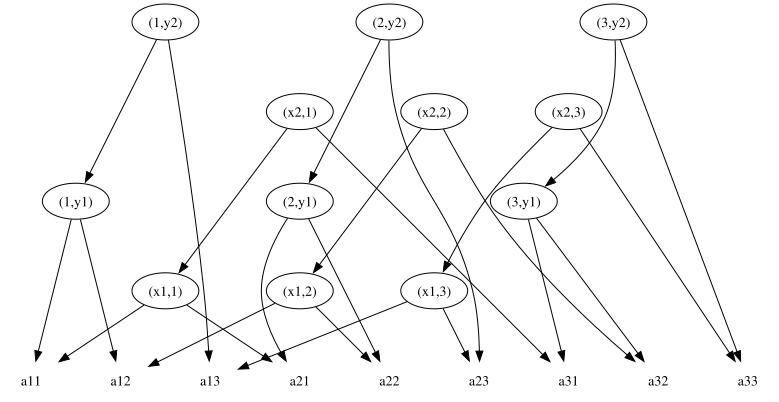

In [532]:
phylonet